# BNS GRB Classification

Classifying Binary Neutron Star mergers from the COMPAS fiducial population (Model A) using the [Gottlieb et al. (2023)](https://arxiv.org/abs/2309.00038) hybrid scenario.

**Classification rules (BNS):**
- `M_tot < 2.8 M☉` → Short cbGRB (HMNS collapse)
- `M_tot ≥ 2.8 M☉` and `q < 1.2` → Short cbGRB (BH + light disk)
- `M_tot ≥ 2.8 M☉` and `q ≥ 1.2` → Long cbGRB (BH + massive disk, GW211211A-like)

**Data:** COMPAS fiducial BNS simulation - [Zenodo 5189849](https://zenodo.org/records/5189849)

## 1. Load Data

In [9]:
import h5py as h5
import numpy as np
import matplotlib.pyplot as plt

path = '/Users/josephrodriguez/research visualization/Data/COMPASCompactOutput_BNS_A.h5'

fdata = h5.File(path, 'r')
fDCO  = fdata['doubleCompactObjects']

mass1               = fDCO['M1'][...].squeeze()
mass2               = fDCO['M2'][...].squeeze()
weights             = fDCO['weight'][...].squeeze()
metallicitySystems  = fDCO['Metallicity1'][...].squeeze()
mergesInHubbleTime  = fDCO['mergesInHubbleTimeFlag'][...].squeeze()
tc                  = fDCO['tc'][...].squeeze()
tform               = fDCO['tform'][...].squeeze()
m1zams              = fDCO['M1ZAMS'][...].squeeze()
m2zams              = fDCO['M2ZAMS'][...].squeeze()

## 2. Gottlieb GRB Classification

Compute total mass `M_tot` and mass ratio `q` for all merging BNS systems, then assign a GRB class following the hybrid scenario.

In [10]:
mask_merging = (mergesInHubbleTime == 1)

M_tot = mass1[mask_merging] + mass2[mask_merging]
q     = np.maximum(mass1[mask_merging], mass2[mask_merging]) / \
        np.minimum(mass1[mask_merging], mass2[mask_merging])

M_crit = 2.8

short_cbGRB = (M_tot < M_crit) | ((M_tot >= M_crit) & (q < 1.2))
long_cbGRB  = (M_tot >= M_crit) & (q >= 1.2)

### Sanity Check

In [11]:
n_merging   = mask_merging.sum()
n_short     = short_cbGRB.sum()
n_long      = long_cbGRB.sum()

print(f"Total BNS systems:       {len(mass1):,}")
print(f"Merging in Hubble time:  {n_merging:,}  ({100*n_merging/len(mass1):.1f}%)")
print(f"Short cbGRB:             {n_short:,}  ({100*n_short/n_merging:.1f}%)")
print(f"Long cbGRB:              {n_long:,}  ({100*n_long/n_merging:.1f}%)")
print(f"\nM_tot range: {M_tot.min():.2f} – {M_tot.max():.2f} M☉")
print(f"q range:     {q.min():.2f} – {q.max():.2f}")

Total BNS systems:       233,137
Merging in Hubble time:  233,137  (100.0%)
Short cbGRB:             189,855  (81.4%)
Long cbGRB:              43,282  (18.6%)

M_tot range: 2.54 – 4.96 M☉
q range:     1.00 – 1.96


## 3. M₁ vs M₂ Mass Plane

Scatter plot of compact object masses colored by GRB class.

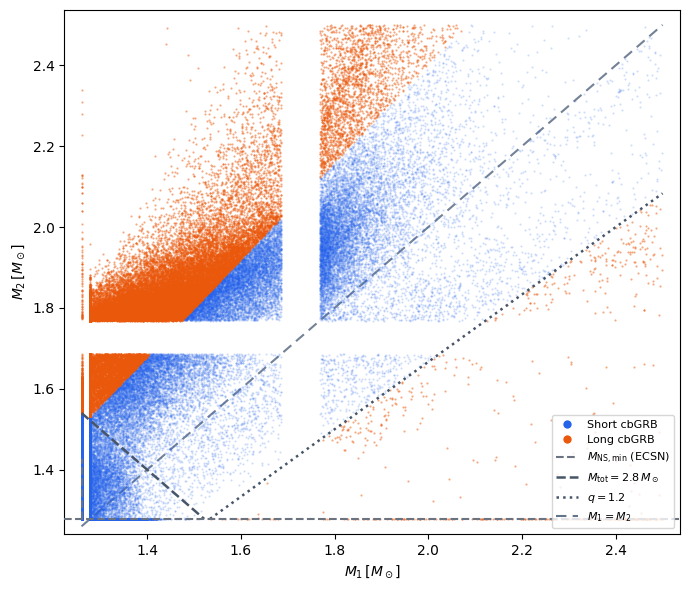

In [12]:
w = weights[mask_merging]
m1 = mass1[mask_merging]
m2 = mass2[mask_merging]

# ECSN floor: NS remnants from electron-capture SNe pile up at a fixed mass
ecsn_m1 = m1.min()   # vertical floor (primary NS)
ecsn_m2 = m2.min()   # horizontal floor (secondary NS)

fig, ax = plt.subplots(figsize=(7, 6))

# Short cbGRB (blue) first, long cbGRB (orange) on top
ax.scatter(m1[short_cbGRB], m2[short_cbGRB],
           s=0.3, alpha=0.20, color='#2563EB', zorder=1, label='Short cbGRB')
ax.scatter(m1[long_cbGRB],  m2[long_cbGRB],
           s=0.3, alpha=0.50, color='#EA580C', zorder=2, label='Long cbGRB')

# ECSN floor reference lines
ax.axhline(ecsn_m2, color='#6B7280', lw=1.5, ls='--', zorder=5)
ax.plot([ecsn_m1, ecsn_m1], [ecsn_m2, ecsn_m2 + 0.15],
        color='#6B7280', lw=1.5, ls='--', zorder=5)

# Classification boundaries — clipped to data range
_x0, _x1 = ecsn_m1, m1.max()
_y0, _y1 = ecsn_m2, m2.max()
_m = np.linspace(_x0, _x1, 200)
# M_tot = 2.8: M2 = 2.8 - M1, only where M2 >= ecsn floor
_mtot_line = 2.8 - _m
_mask_mt = _mtot_line >= _y0
ax.plot(_m[_mask_mt], _mtot_line[_mask_mt],
        color='#475569', lw=1.8, ls='--', zorder=4,
        label=r'$M_\mathrm{tot} = 2.8\,M_\odot$')
# q = 1.2: M2 = M1/1.2, only where M2 >= ecsn floor
_q_line = _m / 1.2
_mask_q = _q_line >= _y0
ax.plot(_m[_mask_q], _q_line[_mask_q],
        color='#475569', lw=1.8, ls=':', zorder=4,
        label=r'$q = 1.2$')
# M1 = M2 diagonal clipped to data range
ax.plot([_x0, min(_x1, _y1)], [_x0, min(_x1, _y1)],
        color='#64748B', lw=1.5, ls=(0, (5, 3)), alpha=0.9, zorder=0)

# Lock axes to data extent with small padding
_pad_x = 0.03 * (_x1 - _x0)
_pad_y = 0.03 * (_y1 - _y0)
ax.set_xlim(_x0 - _pad_x, _x1 + _pad_x)
ax.set_ylim(_y0 - _pad_y, _y1 + _pad_y)

ax.set_xlabel(r'$M_1 \, [M_\odot]$')
ax.set_ylabel(r'$M_2 \, [M_\odot]$')
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#2563EB',
           markersize=7, label='Short cbGRB'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#EA580C',
           markersize=7, label='Long cbGRB'),
    Line2D([0],[0], color='#6B7280', lw=1.5, ls='--',
           label=r'$M_\mathrm{NS,min}$ (ECSN)'),
    Line2D([0],[0], color='#475569', lw=1.8, ls='--',
           label=r'$M_\mathrm{tot} = 2.8\,M_\odot$'),
    Line2D([0],[0], color='#475569', lw=1.8, ls=':',
           label=r'$q = 1.2$'),
    Line2D([0],[0], color='#64748B', lw=1.5, ls=(0, (5, 3)),
           label=r'$M_1 = M_2$'),
], fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/bns_mass_plane.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 4. Formation Efficiency vs Metallicity

Formation efficiency = number of mergers per solar mass of star-forming material. Computed at each of the 53 metallicity grid points using STROOPWAFEL sampling weights.

In [13]:
metallicityGrid = [0.0001, 0.00011, 0.00012, 0.00014, 0.00016, 0.00017,
                   0.00019, 0.00022, 0.00024, 0.00027, 0.0003,  0.00034,
                   0.00037, 0.00042, 0.00047, 0.00052, 0.00058, 0.00065,
                   0.00073, 0.00081, 0.0009,  0.00101, 0.00113, 0.00126,
                   0.0014,  0.00157, 0.00175, 0.00195, 0.00218, 0.00243,
                   0.00272, 0.00303, 0.00339, 0.00378, 0.00422, 0.00471,
                   0.00526, 0.00587, 0.00655, 0.00732, 0.00817, 0.00912,
                   0.01018, 0.01137, 0.01269, 0.01416, 0.01581, 0.01765,
                   0.01971, 0.022,   0.0244,  0.02705, 0.03]

meanMassEvolved = 77708655  # avg stellar mass per metallicity simulation

Z_all   = metallicitySystems[mask_merging]
w_all   = weights[mask_merging]

eff_total = np.zeros(len(metallicityGrid))
eff_short = np.zeros(len(metallicityGrid))
eff_long  = np.zeros(len(metallicityGrid))

unique_Z = np.unique(metallicitySystems)

for i, Z in enumerate(metallicityGrid):
    if Z in unique_Z:
        maskZ = (Z_all == Z)
        eff_total[i] = np.sum(w_all[maskZ])                    / meanMassEvolved
        eff_short[i] = np.sum(w_all[maskZ & short_cbGRB])      / meanMassEvolved
        eff_long[i]  = np.sum(w_all[maskZ & long_cbGRB])       / meanMassEvolved

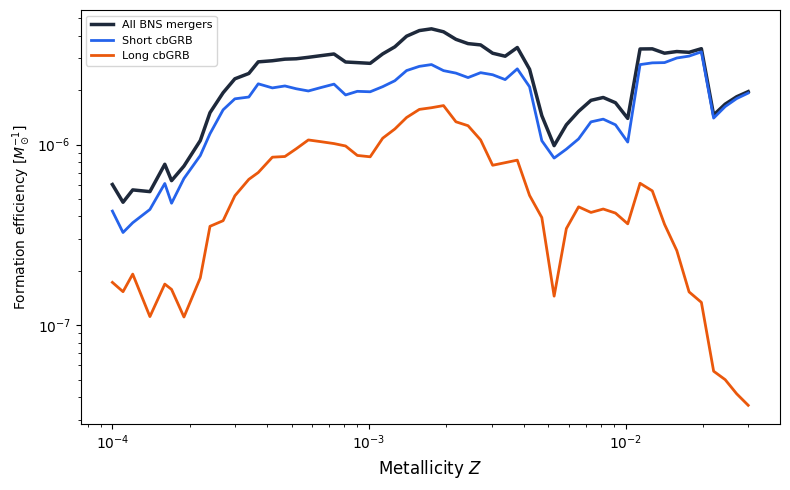

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(metallicityGrid, eff_total, color='#1E293B',      lw=2.5, label='All BNS mergers')
ax.plot(metallicityGrid, eff_short, color='#2563EB',  lw=2,   label='Short cbGRB')
ax.plot(metallicityGrid, eff_long,  color='#EA580C', lw=2,   label='Long cbGRB')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Metallicity $Z$', fontsize=12)
ax.set_ylabel(r'Formation efficiency $[M_\odot^{-1}]$')
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/bns_formation_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

### GRB Class Fraction vs Metallicity

Fraction of BNS mergers in each GRB class as a function of birth metallicity.

Max |short + long - 1| across metallicities: 1.11e-16


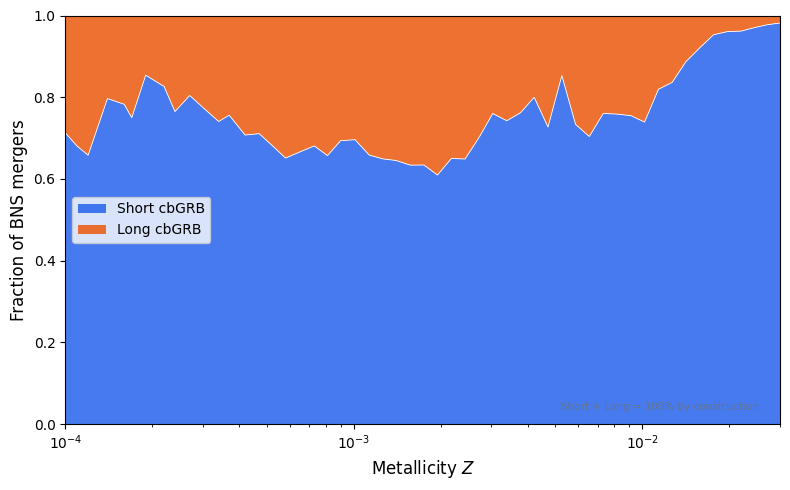

In [15]:
# Normalise by short+long directly so fractions sum to exactly 1.0 by construction
with np.errstate(invalid='ignore', divide='ignore'):
    denom      = eff_short + eff_long
    frac_short = np.where(denom > 0, eff_short / denom, np.nan)
    frac_long  = np.where(denom > 0, eff_long  / denom, np.nan)

# Diagnostic: confirm sum at each metallicity
valid = denom > 0
if valid.any():
    residual = np.abs(frac_short[valid] + frac_long[valid] - 1.0).max()
    print(f"Max |short + long - 1| across metallicities: {residual:.2e}")

# Stacked area chart — short + long = 100% at every Z by construction
fig, ax = plt.subplots(figsize=(8, 5))
Z = np.array(metallicityGrid)
ax.stackplot(Z, frac_short, frac_long,
             colors=['#2563EB', '#EA580C'],
             labels=['Short cbGRB', 'Long cbGRB'],
             alpha=0.85)
ax.plot(Z, frac_short, color='white', lw=0.6)   # boundary line
ax.set_xscale('log')
ax.set_xlim(Z[valid][0], Z[valid][-1])
ax.set_ylim(0, 1)
ax.set_xlabel('Metallicity $Z$', fontsize=12)
ax.set_ylabel('Fraction of BNS mergers', fontsize=12)
ax.legend(loc='center left', fontsize=10)
ax.text(0.97, 0.03, 'Short + Long = 100% by construction',
        transform=ax.transAxes, fontsize=7.5, color='#64748B',
        ha='right', va='bottom')
plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/bns_grb_fraction_vs_metallicity.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Delay Time Distribution

Total delay time = stellar evolution time + coalescence time.

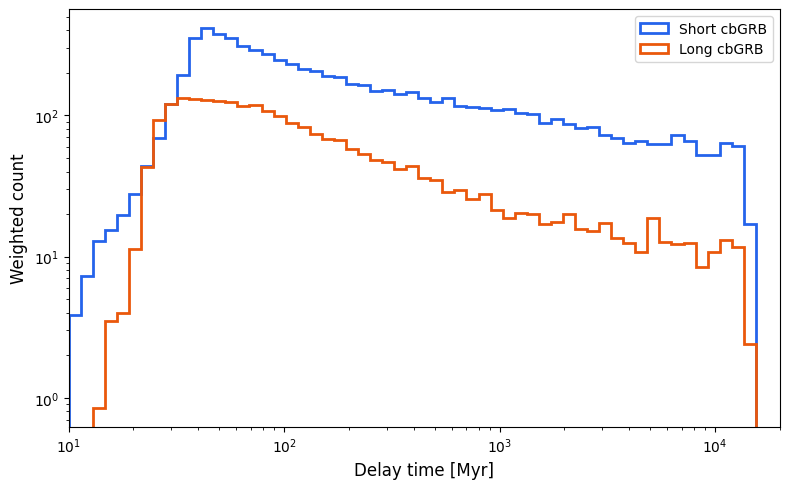

In [16]:
delay_times = (tform + tc)[mask_merging]   # total delay time in Myr
w_m = weights[mask_merging]

t_short = delay_times[short_cbGRB]
t_long  = delay_times[long_cbGRB]
w_short = w_m[short_cbGRB]
w_long  = w_m[long_cbGRB]

bins = np.logspace(1, np.log10(2e4), 60)   # 10 Myr to 20,000 Myr

fig, ax = plt.subplots(figsize=(8, 5))

# Step histograms: overlapping so absolute counts per channel are directly readable
ax.hist(t_short, bins=bins, weights=w_short,
        histtype='step', color='#2563EB', lw=2, label='Short cbGRB')
ax.hist(t_long,  bins=bins, weights=w_long,
        histtype='step', color='#EA580C', lw=2, label='Long cbGRB')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(10, 2e4)
ax.set_xlabel('Delay time [Myr]', fontsize=12)
ax.set_ylabel('Weighted count', fontsize=12)
ax.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/bns_delay_time_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 5. Model Comparison: A vs K

Model K uses a different binary physics prescription. Comparing the two shows robustness of the GRB classification results.

In [17]:
path_K = '/Users/josephrodriguez/research visualization/Data/COMPASCompactOutput_BNS_K.h5'

fdata_K = h5.File(path_K, 'r')
fDCO_K  = fdata_K['doubleCompactObjects']

mass1_K              = fDCO_K['M1'][...].squeeze()
mass2_K              = fDCO_K['M2'][...].squeeze()
weights_K            = fDCO_K['weight'][...].squeeze()
metallicity_K        = fDCO_K['Metallicity1'][...].squeeze()
merges_K             = fDCO_K['mergesInHubbleTimeFlag'][...].squeeze()
tc_K                 = fDCO_K['tc'][...].squeeze()
tform_K              = fDCO_K['tform'][...].squeeze()

mask_K   = (merges_K == 1)
M_tot_K  = mass1_K[mask_K] + mass2_K[mask_K]
q_K      = np.maximum(mass1_K[mask_K], mass2_K[mask_K]) / \
           np.minimum(mass1_K[mask_K], mass2_K[mask_K])

short_K  = (M_tot_K < M_crit) | ((M_tot_K >= M_crit) & (q_K < 1.2))
long_K   = (M_tot_K >= M_crit) & (q_K >= 1.2)

print(f"Model K - Short cbGRB: {short_K.sum():,} ({100*short_K.sum()/mask_K.sum():.1f}%)")
print(f"Model K - Long cbGRB:  {long_K.sum():,}  ({100*long_K.sum()/mask_K.sum():.1f}%)")

Model K - Short cbGRB: 191,290 (81.4%)
Model K - Long cbGRB:  43,673  (18.6%)


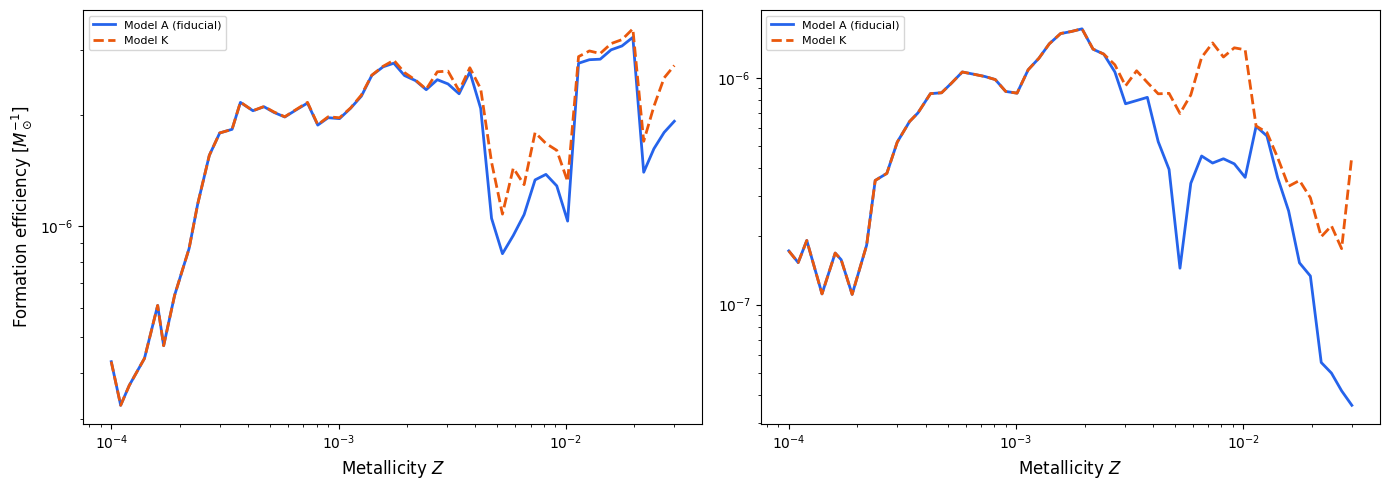

In [18]:
Z_K = metallicity_K[mask_K]
w_K = weights_K[mask_K]
unique_ZK = np.unique(metallicity_K)

eff_total_K = np.zeros(len(metallicityGrid))
eff_short_K = np.zeros(len(metallicityGrid))
eff_long_K  = np.zeros(len(metallicityGrid))

for i, Z in enumerate(metallicityGrid):
    if Z in unique_ZK:
        maskZ = (Z_K == Z)
        eff_total_K[i] = np.sum(w_K[maskZ])               / meanMassEvolved
        eff_short_K[i] = np.sum(w_K[maskZ & short_K])     / meanMassEvolved
        eff_long_K[i]  = np.sum(w_K[maskZ & long_K])      / meanMassEvolved

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, eff_A, eff_B, label in [
    (axes[0], eff_short, eff_short_K, 'Short cbGRB'),
    (axes[1], eff_long,  eff_long_K,  'Long cbGRB')
]:
    ax.plot(metallicityGrid, eff_A, color='#2563EB', lw=2, label='Model A (fiducial)')
    ax.plot(metallicityGrid, eff_B, color='#EA580C', lw=2, ls='--', label='Model K')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Metallicity $Z$', fontsize=12)
    if ax is axes[0]:
        ax.set_ylabel(r'Formation efficiency $[M_\odot^{-1}]$', fontsize=12)
    ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/bns_model_ak_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Uncertainty Analysis

Sensitivity of the GRB class fractions to the two free classification parameters.

### 6a. M_crit Sensitivity (NS Equation of State)

Vary the critical total mass `M_crit` from 2.6–3.0 M☉ to probe EOS uncertainty.

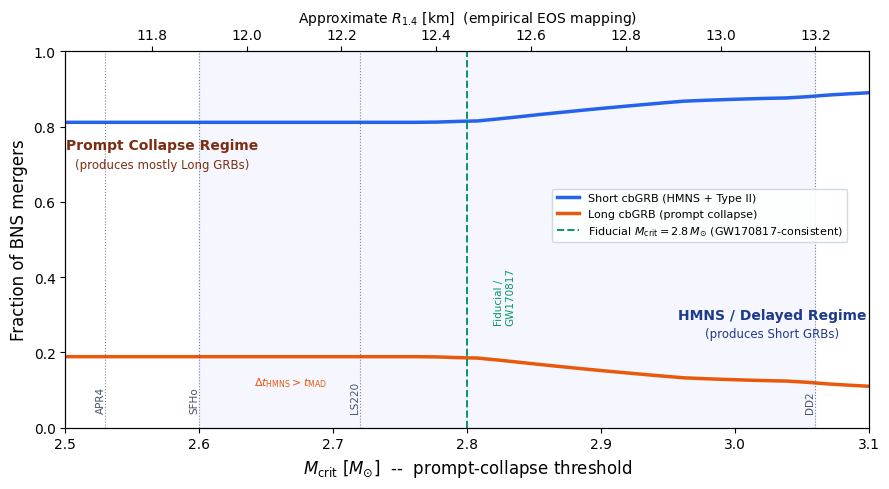

In [19]:
M_crit_range = np.linspace(2.5, 3.1, 40)
frac_long_vs_Mcrit  = []
frac_short_vs_Mcrit = []

for Mc in M_crit_range:
    s = (M_tot < Mc) | ((M_tot >= Mc) & (q < 1.2))
    l = (M_tot >= Mc) & (q >= 1.2)
    n = len(M_tot)
    frac_short_vs_Mcrit.append(s.sum() / n)
    frac_long_vs_Mcrit.append(l.sum() / n)

def mcrit_to_r14(mc):
    return 11.9 + (13.2 - 11.9) / (3.06 - 2.60) * (mc - 2.60)

eos_models = {'APR4': 2.53, 'SFHo': 2.60, 'LS220': 2.72, 'DD2': 3.06}

fig, ax = plt.subplots(figsize=(9, 5))

ax.axvspan(2.60, 3.06, alpha=0.06, color='#6366F1')

ax.plot(M_crit_range, frac_short_vs_Mcrit,
        color='#2563EB', lw=2.5, label='Short cbGRB (HMNS + Type II)')
ax.plot(M_crit_range, frac_long_vs_Mcrit,
        color='#EA580C', lw=2.5, label='Long cbGRB (prompt collapse)')

# Fiducial M_crit=2.8; GW170817 constraints (R_1.4~12.5 km) map to M_crit~2.81
# — lines are only 0.01 M_sun apart; combined into one annotated line
ax.axvline(2.8, color='#059669', ls='--', lw=1.4,
           label='Fiducial $M_{\\mathrm{crit}} = 2.8\\,M_{\\odot}$ (GW170817-consistent)')
ax.text(2.82, 0.35, 'Fiducial /\nGW170817', rotation=90,
        fontsize=7.5, color='#059669', va='center', ha='left')

for name, mc in eos_models.items():
    if M_crit_range[0] <= mc <= M_crit_range[-1]:
        ax.axvline(mc, color='#475569', lw=0.8, ls=':', alpha=0.7)
        ax.text(mc, 0.04, name, rotation=90, fontsize=7.5,
                color='#475569', ha='right', va='bottom')


# Territory labels: color matches dominant data line in each region
# Left (low M_crit): prompt collapse regime — Long cbGRB dominates
ax.text(0.12, 0.75, 'Prompt Collapse Regime', fontsize=10, transform=ax.transAxes,
        color='#7C2D12', ha='center', va='center', fontweight='bold')
ax.text(0.12, 0.70, '(produces mostly Long GRBs)', fontsize=8.5, transform=ax.transAxes,
        color='#7C2D12', ha='center', va='center')

# Right (high M_crit): HMNS regime — Short cbGRB (Type I) dominates
ax.text(0.88, 0.30, 'HMNS / Delayed Regime', fontsize=10, transform=ax.transAxes,
        color='#1E3A8A', ha='center', va='center', fontweight='bold')
ax.text(0.88, 0.25, '(produces Short GRBs)', fontsize=8.5, transform=ax.transAxes,
        color='#1E3A8A', ha='center', va='center')

# MAD note centered in the SFHo-LS220 gap
ax.text(0.28, 0.12, '$\\Delta t_{\\rm HMNS} > t_{\\rm MAD}$', transform=ax.transAxes,
        fontsize=8, color='#EA580C', ha='center', va='center', style='italic')

# Legend raised to give labels below plenty of room
ax.legend(fontsize=8, loc='upper right',
          bbox_to_anchor=(0.98, 0.65),
          frameon=True, framealpha=0.9, edgecolor='#CBD5E1')

ax.set_xlim(M_crit_range[0], M_crit_range[-1])
ax.set_ylim(0, 1)
ax.set_xlabel(
    '$M_{\\mathrm{crit}}$ [$M_{\\odot}$]  --  prompt-collapse threshold',
    fontsize=12)
ax.set_ylabel('Fraction of BNS mergers', fontsize=12)

ax2 = ax.twiny()
ax2.set_xlim(mcrit_to_r14(M_crit_range[0]), mcrit_to_r14(M_crit_range[-1]))
ax2.set_xlabel(
    'Approximate $R_{1.4}$ [km]  (empirical EOS mapping)',
    fontsize=10)

plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/bns_mcrit_sensitivity.png',
            dpi=150, bbox_inches='tight')
plt.show()


### 6b. Mass Ratio Threshold Sensitivity

Vary the `q = 1.2` boundary that separates short from long cbGRB.

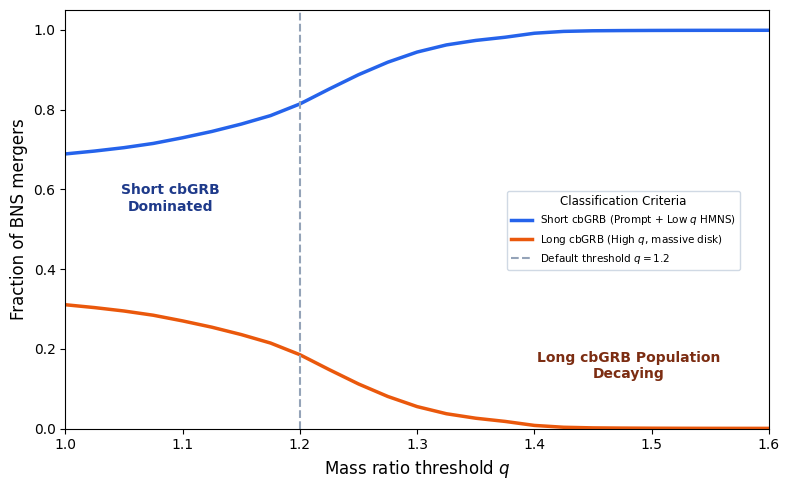

In [20]:
q_thresh_range = np.linspace(1.0, 1.6, 25)
frac_long_q  = []
frac_short_q = []

for qt in q_thresh_range:
    s = (M_tot < M_crit) | ((M_tot >= M_crit) & (q < qt))
    l = (M_tot >= M_crit) & (q >= qt)
    frac_short_q.append(s.sum() / len(M_tot))
    frac_long_q.append(l.sum()  / len(M_tot))

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(q_thresh_range, frac_short_q, color='#2563EB', lw=2.5,
        label='Short cbGRB (Prompt + Low $q$ HMNS)')
ax.plot(q_thresh_range, frac_long_q,  color='#EA580C', lw=2.5,
        label='Long cbGRB (High $q$, massive disk)')
ax.axvline(1.2, color='#94A3B8', ls='--', lw=1.5,
           label='Default threshold $q = 1.2$')

# Territory annotations
ax.text(0.15, 0.55, 'Short cbGRB\nDominated', fontsize=10, transform=ax.transAxes,
        color='#1E3A8A', ha='center', va='center', fontweight='bold')
ax.text(0.80, 0.15, 'Long cbGRB Population\nDecaying', fontsize=10, transform=ax.transAxes,
        color='#7C2D12', ha='center', va='center', fontweight='bold')

ax.set_xlim(q_thresh_range[0], q_thresh_range[-1])
ax.set_ylim(0, 1.05)
ax.set_xlabel('Mass ratio threshold $q$', fontsize=12)
ax.set_ylabel('Fraction of BNS mergers', fontsize=12)

ax.legend(title='Classification Criteria', title_fontsize=8.5,
          fontsize=7.5, loc='upper left', bbox_to_anchor=(0.62, 0.58),
          frameon=True, framealpha=0.9, edgecolor='#CBD5E1')
plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/bns_q_threshold_sensitivity.png',
            dpi=150, bbox_inches='tight')
plt.show()


### 6c. Mass Ratio Distribution

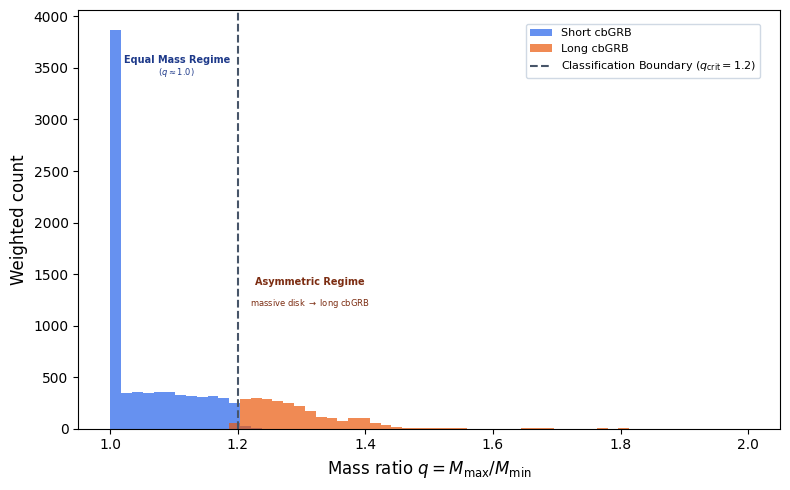

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
bins = np.linspace(1.0, 2.0, 60)

ax.hist(q[short_cbGRB], bins=bins, weights=weights[mask_merging][short_cbGRB],
        color='#2563EB', alpha=0.70, label='Short cbGRB')
ax.hist(q[long_cbGRB],  bins=bins, weights=weights[mask_merging][long_cbGRB],
        color='#EA580C', alpha=0.70, label='Long cbGRB')
ax.axvline(1.2, color='#475569', ls='--', lw=1.5,
           label='Classification Boundary ($q_{\\rm crit} = 1.2$)')

# Left zone: Equal Mass Regime — upper-left, clear of legend
ax.text(0.14, 0.88, 'Equal Mass Regime', fontsize=7, transform=ax.transAxes,
        color='#1E3A8A', ha='center', va='center', fontweight='bold')
ax.text(0.14, 0.85, '($q \\approx 1.0$)', fontsize=6, transform=ax.transAxes,
        color='#1E3A8A', ha='center', va='center')

# Right zone: Asymmetric Regime — lower-right, below legend
ax.text(0.33, 0.35, 'Asymmetric Regime', fontsize=7, transform=ax.transAxes,
        color='#7C2D12', ha='center', va='center', fontweight='bold')
ax.text(0.33, 0.30, 'massive disk $\\to$ long cbGRB', fontsize=6,
        transform=ax.transAxes, color='#7C2D12', ha='center', va='center')

ax.set_xlabel('Mass ratio $q = M_{\\rm max}/M_{\\rm min}$', fontsize=12)
ax.set_ylabel('Weighted count', fontsize=12)
ax.legend(fontsize=8, loc='upper right', bbox_to_anchor=(0.98, 0.98),
          frameon=True, framealpha=0.9, edgecolor='#CBD5E1')
plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/bns_mass_ratio_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()


### 6d. Progenitor ZAMS Mass Plane

Which zero-age main sequence stellar systems produce each GRB class?

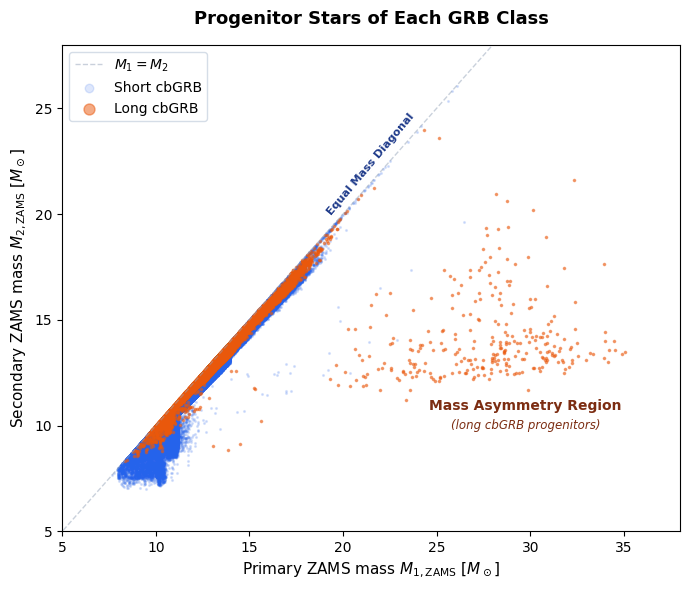

In [22]:
m1zams_merging = m1zams[mask_merging]
m2zams_merging = m2zams[mask_merging]

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot([0, 80], [0, 80], color='#94A3B8', ls='--', lw=1, alpha=0.5,
        label='$M_1 = M_2$')
ax.scatter(m1zams_merging[short_cbGRB], m2zams_merging[short_cbGRB],
           s=1.5, alpha=0.15, color='#2563EB', label='Short cbGRB', rasterized=True)
ax.scatter(m1zams_merging[long_cbGRB],  m2zams_merging[long_cbGRB],
           s=2.5, alpha=0.5,  color='#EA580C', label='Long cbGRB',  rasterized=True)

ax.set_xlim(5, 38)
ax.set_ylim(5, 28)

ax.text(0.50, 0.65, 'Equal Mass Diagonal', fontsize=8, transform=ax.transAxes,
        color='#1E3A8A', fontweight='bold', rotation=50, ha='center')
ax.text(0.75, 0.25, 'Mass Asymmetry Region', fontsize=10, transform=ax.transAxes,
        color='#7C2D12', fontweight='bold', ha='center')
ax.text(0.75, 0.21, '(long cbGRB progenitors)', fontsize=8.5, transform=ax.transAxes,
        color='#7C2D12', ha='center', style='italic')

ax.legend(markerscale=5, loc='upper left', frameon=True, edgecolor='#CBD5E1')
ax.set_xlabel(r'Primary ZAMS mass $M_{1,\rm ZAMS}$ [$M_\odot$]', fontsize=11)
ax.set_ylabel(r'Secondary ZAMS mass $M_{2,\rm ZAMS}$ [$M_\odot$]', fontsize=11)
ax.set_title('Progenitor Stars of Each GRB Class', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/bns_progenitor_zams_plane.png',
            dpi=150, bbox_inches='tight')
plt.show()


## Export

Save formation efficiency arrays for use in the comparison notebook.

In [23]:
import numpy as np
np.save('/Users/josephrodriguez/research visualization/results/eff_BNS.npy', 
        np.array([eff_total, eff_short, eff_long]))
print("BNS efficiencies saved.")

BNS efficiencies saved.
